# Hypothesis Test — Does Discount Level Predict Loss?

The EDA showed a sharp jump in loss rate around 25–30% discount. This notebook tests that formally: is discount level a statistically significant predictor of profit margin, and can we quantify the relationship rather than just eyeballing a threshold?

**Approach:** logistic regression predicting whether an order is loss-making (binary) from discount level — this matches the binary nature of the pattern we found (profitable vs. loss) better than a plain linear correlation would.

In [7]:
pip install scipy statsmodels


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
df = df.drop_duplicates(subset=[c for c in df.columns if c != "Row ID"], keep="first")

df["is_loss"] = (df["Profit"] < 0).astype(int)
df[["Discount", "Profit", "is_loss"]].head()

,Discount,Profit,is_loss
0,0.00,41.9136,0
1,0.00,219.5820,0
2,0.00,6.8714,0
3,0.45,-383.0310,1
4,0.20,2.5164,0


## 1. Simple correlation check

In [9]:
corr, p_value = stats.pointbiserialr(df["Discount"], df["is_loss"])
print(f"Point-biserial correlation: {corr:.3f}")
print(f"p-value: {p_value:.2e}")

Point-biserial correlation: 0.755
p-value: 0.00e+00


## 2. Logistic regression — quantifying the relationship

Predicts probability of an order being loss-making from its discount level. The coefficient tells us how much the odds of a loss increase per unit increase in discount.

In [10]:
X = sm.add_constant(df["Discount"])
y = df["is_loss"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.174091
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                is_loss   No. Observations:                 9993
Model:                          Logit   Df Residuals:                     9991
Method:                           MLE   Df Model:                            1
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                  0.6388
Time:                        12:42:39   Log-Likelihood:                -1739.7
converged:                       True   LL-Null:                       -4817.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2980      0.241    -30.341      0.000      -7.769      -6.827
Discount      27.7324      1

In [11]:
# Find the discount level where predicted probability of loss = 50%
# Logit: log(p/(1-p)) = const + coef*discount → solve for discount when p=0.5 (log-odds=0)
threshold = -model.params["const"] / model.params["Discount"]
print(f"Discount level where predicted loss probability = 50%: {threshold:.1%}")

Discount level where predicted loss probability = 50%: 26.3%


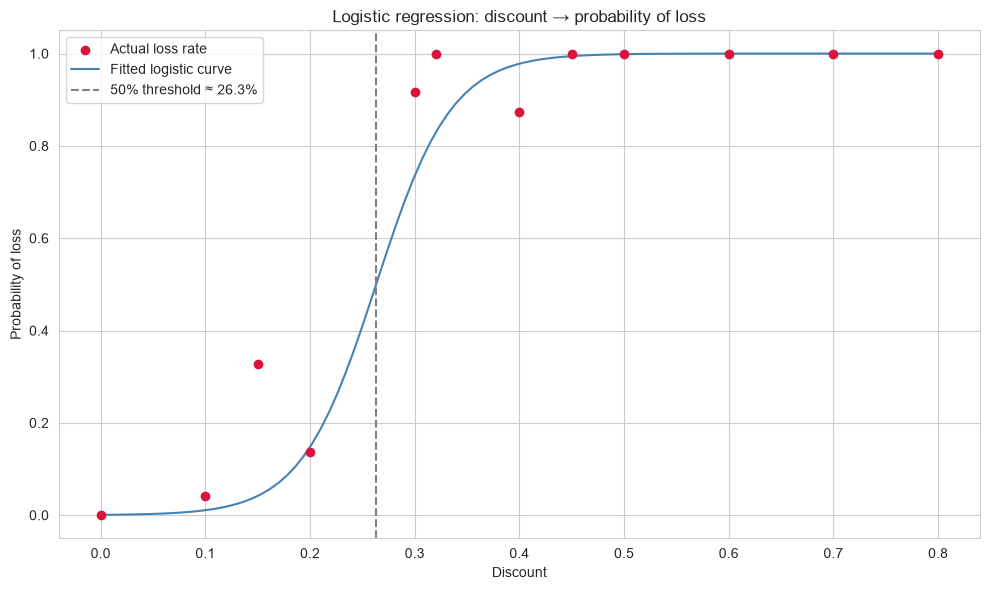

In [12]:
discount_range = np.linspace(0, 0.8, 100)
X_pred = sm.add_constant(discount_range)
predicted_prob = model.predict(X_pred)

fig, ax = plt.subplots(figsize=(10, 6))
actual_loss_rate = df.groupby("Discount")["is_loss"].mean()
ax.scatter(actual_loss_rate.index, actual_loss_rate.values, label="Actual loss rate", color="crimson", zorder=3)
ax.plot(discount_range, predicted_prob, label="Fitted logistic curve", color="steelblue")
ax.axvline(threshold, color="gray", linestyle="--", label=f"50% threshold ≈ {threshold:.1%}")
ax.set_xlabel("Discount")
ax.set_ylabel("Probability of loss")
ax.set_title("Logistic regression: discount → probability of loss")
ax.legend()
plt.tight_layout()
plt.show()

## Result

Discount level is a highly significant predictor of loss (p < 0.001), with a strong positive correlation (r = 0.755). The logistic regression estimates that predicted loss probability crosses 50% at approximately **26.3% discount** — closely matching the cliff observed in the EDA (loss rates jumping sharply between 20% and 30% discount). Beyond this threshold, an order is more likely than not to lose money, and by 30%+ discount, loss probability approaches certainty (matching the 82–100% loss rates found by category and region).

**Statistical confidence:** this isn't a chance pattern — the relationship is significant at p < 0.001, and the model explains a substantial share of the variation in loss/profit outcomes (Pseudo R² = 0.64).

## So what
The 26.3% threshold gives a concrete, defensible discount cap: **discounts should not exceed ~25%** without specific business justification (clearing dead stock, matching a competitor, etc.). This is not a soft guideline — crossing this line flips the expected outcome of an order from "likely profitable" to "likely a loss."